# Debugging DR Projections

This notebook demonstrates how to debug and visualize dimensionality reduction outputs
for substrates, both using matplotlib and the interactive widget.

In [1]:
import networkx as nx
from node_substrates import NodeSubstratesWidget, plot_dr_comparison, inspect_attributes

## 1. Create Sample Graph

In [2]:
G = nx.karate_club_graph()

# Add node attributes
for node in G.nodes():
    G.nodes[node]['degree'] = G.degree(node)
    G.nodes[node]['clustering'] = nx.clustering(G, node)
    G.nodes[node]['betweenness'] = nx.betweenness_centrality(G)[node]
    G.nodes[node]['closeness'] = nx.closeness_centrality(G)[node]

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Graph: 34 nodes, 78 edges


## 2. Inspect Attributes

Check what numeric attributes are available for DR.

In [3]:
inspect_attributes(G)

Graph: 34 nodes

Attributes:
--------------------------------------------------
  club: str
    - unique values: 2
    - values: {'Officer', 'Mr. Hi'}

  degree: int
    - min: 1.0000
    - max: 17.0000
    - mean: 4.5882
    - std: 3.8204

  clustering: float
    - min: 0.0000
    - max: 1.0000
    - mean: 0.5706
    - std: 0.3423

  betweenness: float
    - min: 0.0000
    - max: 0.4376
    - mean: 0.0440
    - std: 0.0925

  closeness: float
    - min: 0.2845
    - max: 0.5690
    - mean: 0.4265
    - std: 0.0710



## 3. Compare DR Methods (Standalone)

Plot PCA, UMAP, and t-SNE side by side without creating a widget.

/home/christinoleo/Projects/papers/nodeSubstrates/implementation/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


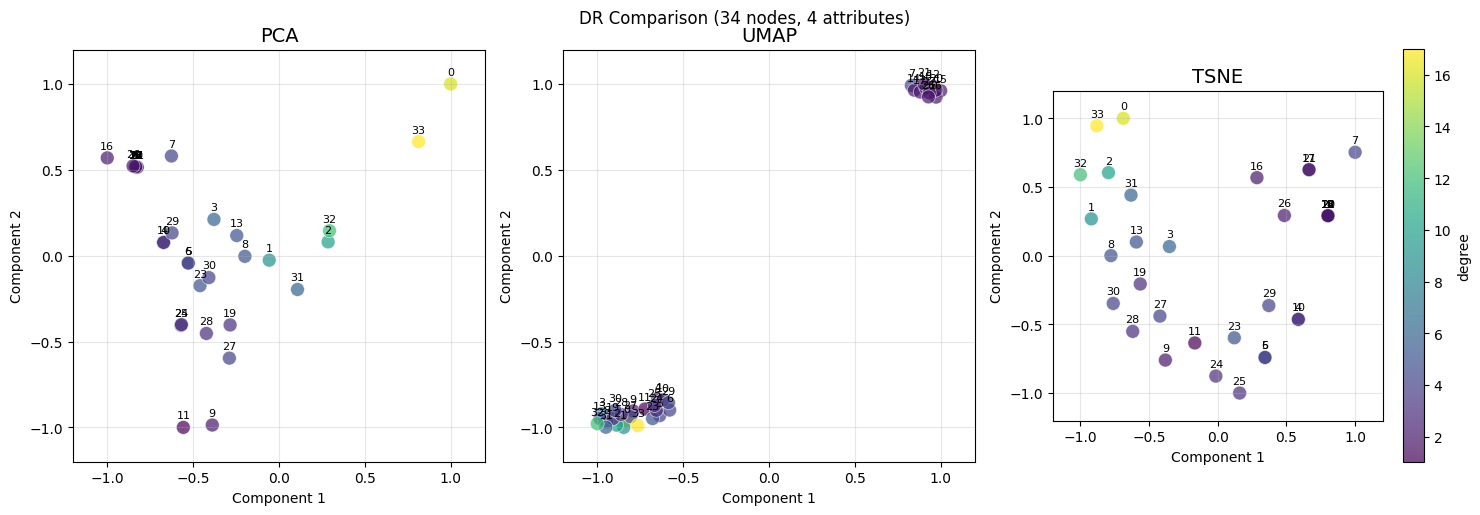

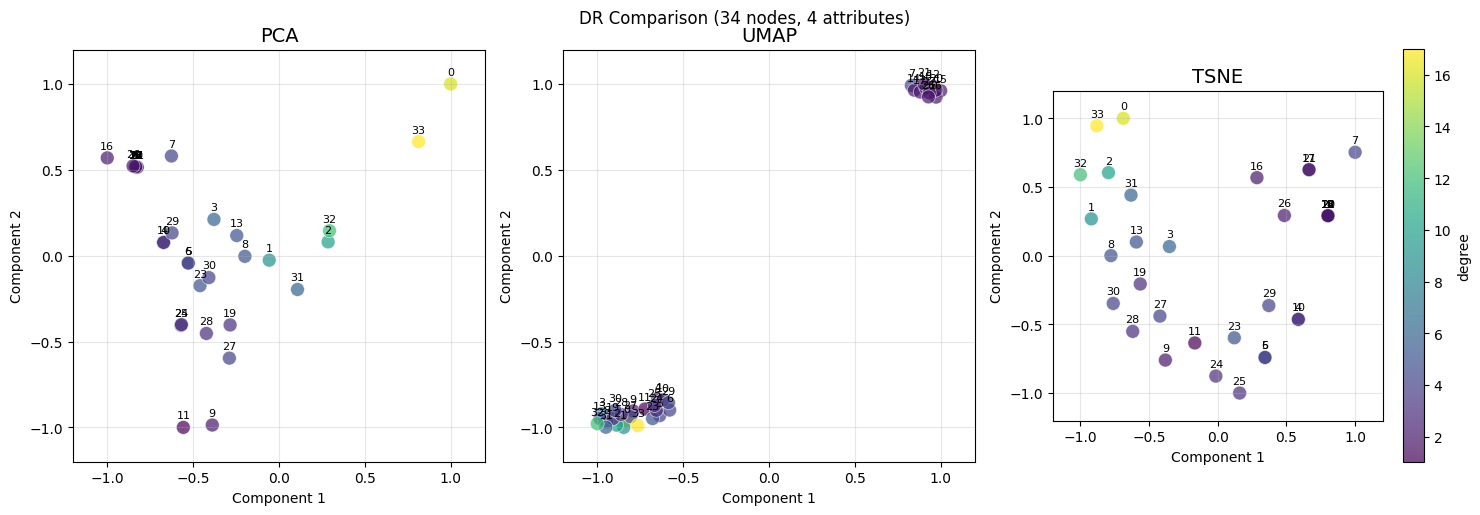

In [4]:
plot_dr_comparison(G, color_by='degree')

## 4. Create Widget with Auto-Substrate

In [5]:
widget = NodeSubstratesWidget(G, auto_substrate=True)
widget

## 5. Inspect Substrates

In [6]:
# List all substrates
for s in widget.substrate_views:
    print(s)

SubstrateView(id='substrate_0', label='Community 3', nodes=13)


## 6. Plot Substrate with Matplotlib

Use `.plot()` for quick static visualization.

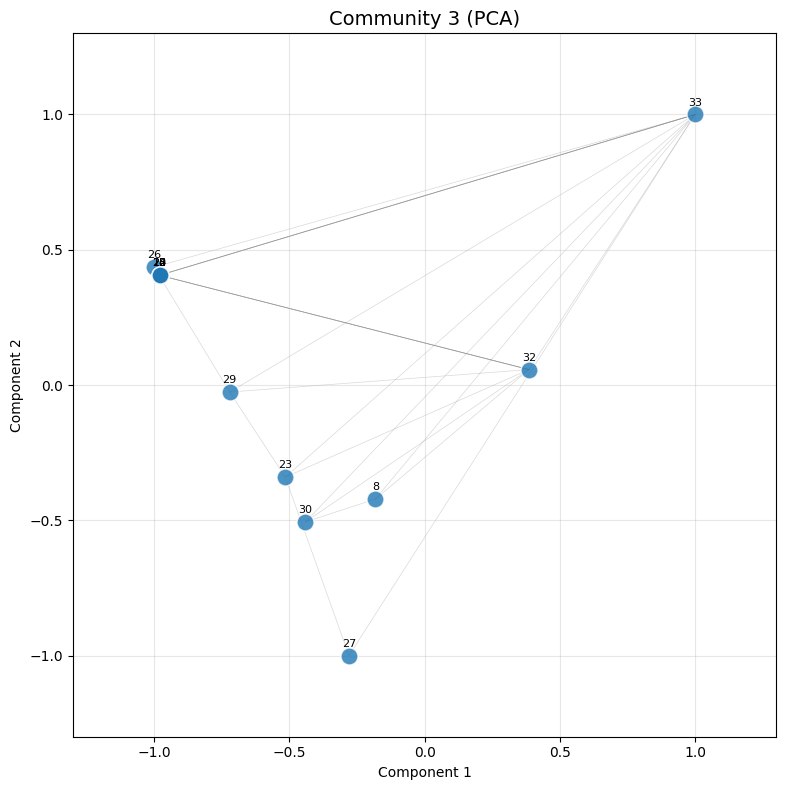

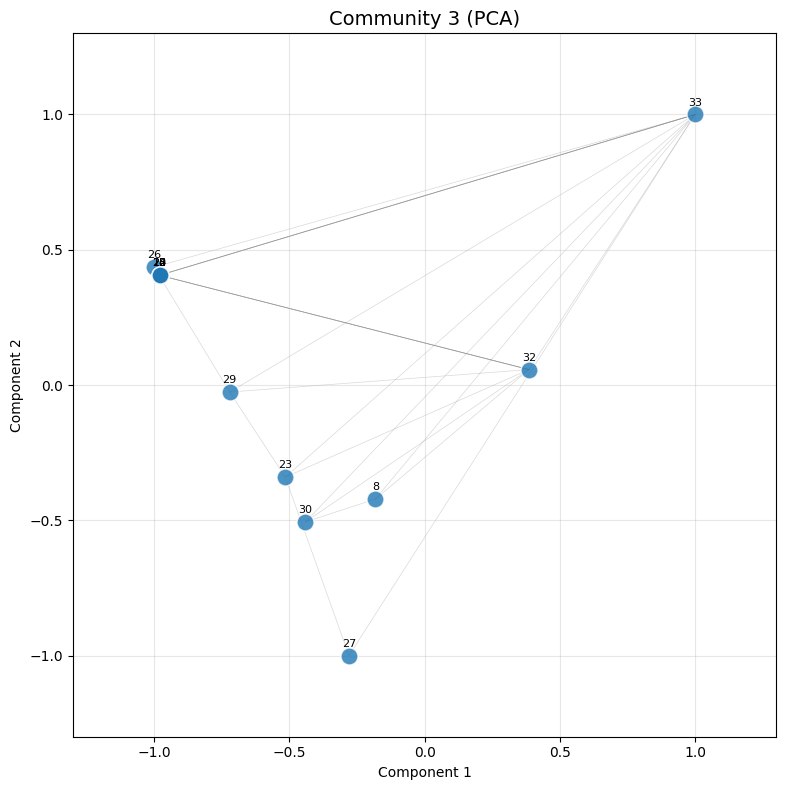

In [7]:
# Plot the first substrate
widget.substrate(0).plot()

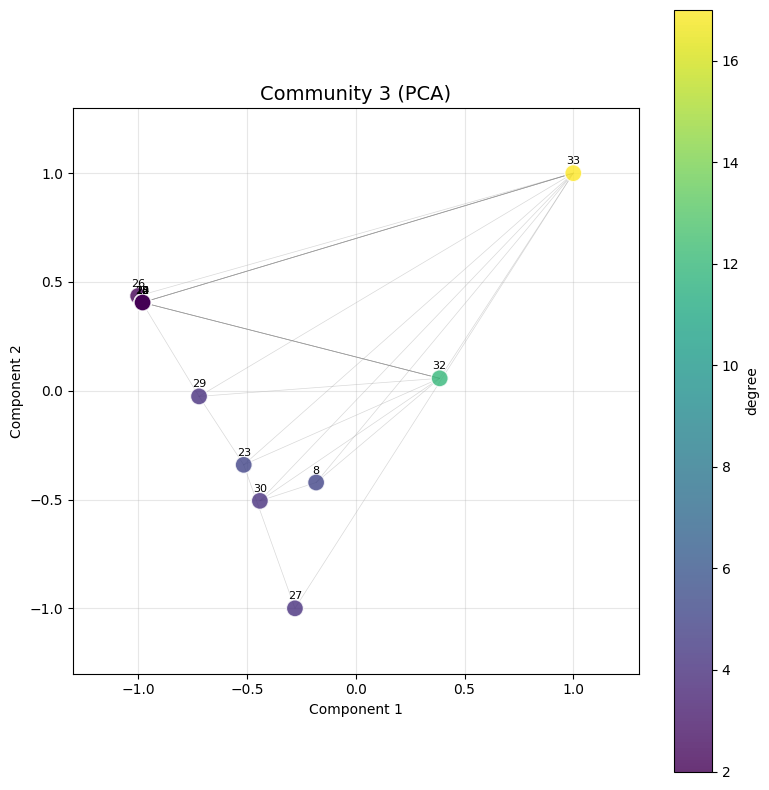

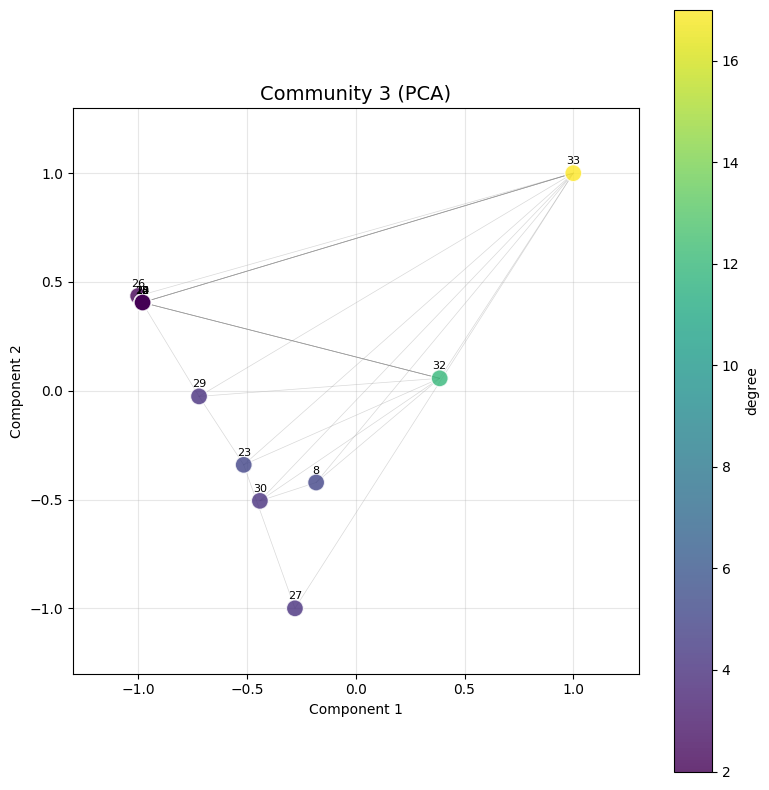

In [8]:
# Plot with color by attribute
widget.substrate(0).plot(color_by='degree', show_labels=True)

## 7. Show Substrate in Mini-Widget

Use `.show()` to view the substrate in an interactive widget (reuses JS code).

In [9]:
widget.substrate(0).show()

## 8. Plot DR from Widget

You can also plot DR directly from the widget.

/home/christinoleo/Projects/papers/nodeSubstrates/implementation/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


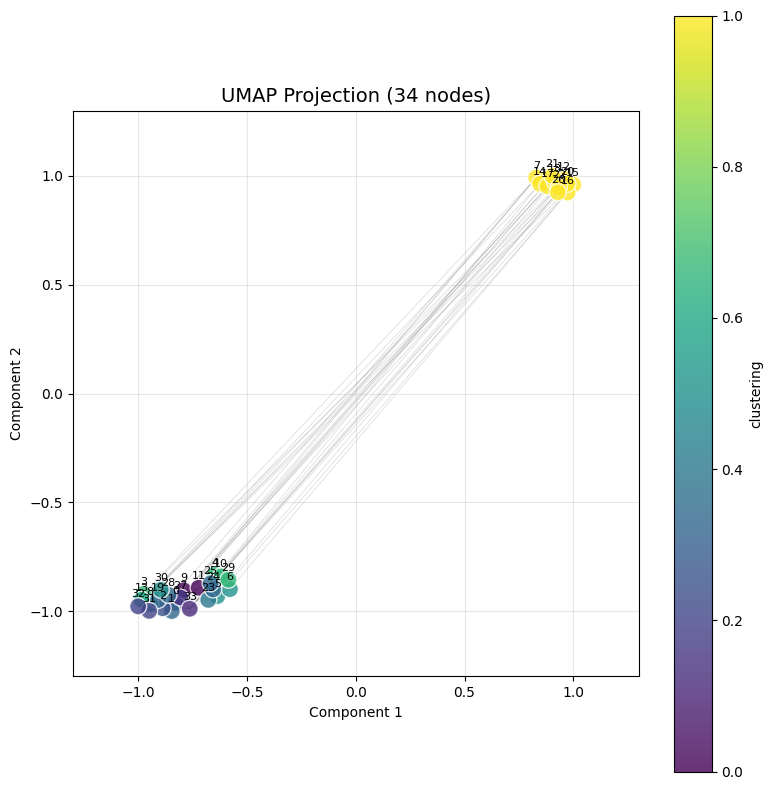

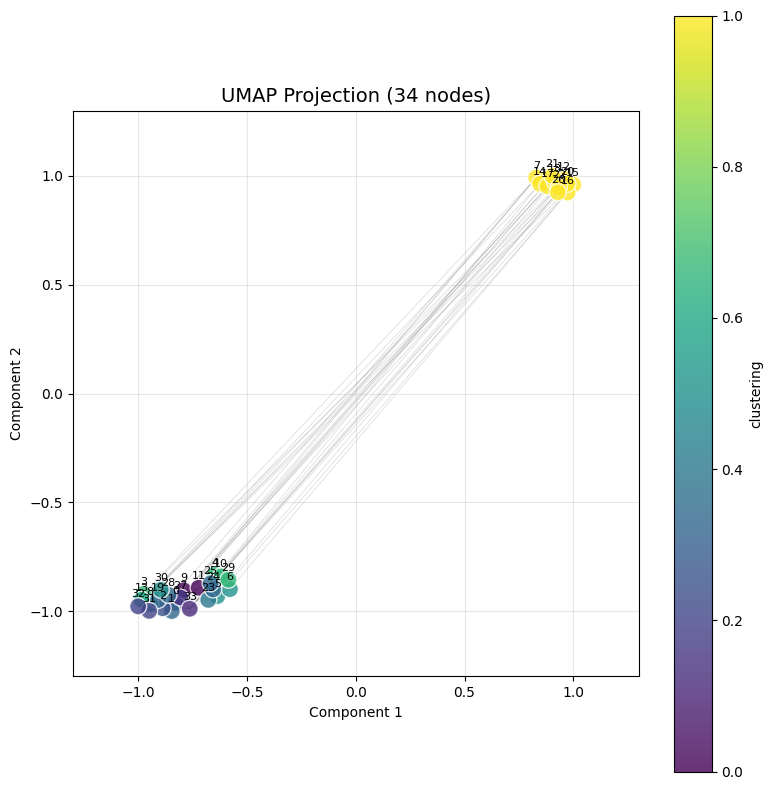

In [10]:
# Plot all nodes with UMAP
widget.plot_dr('umap', color_by='clustering')

/home/christinoleo/Projects/papers/nodeSubstrates/implementation/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


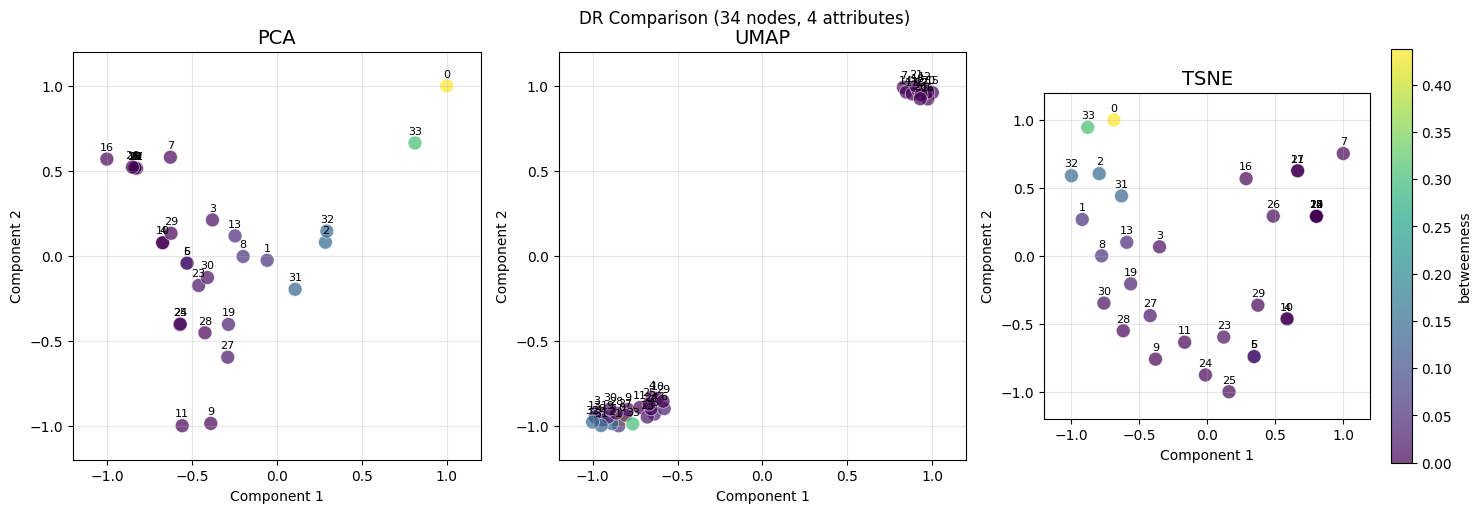

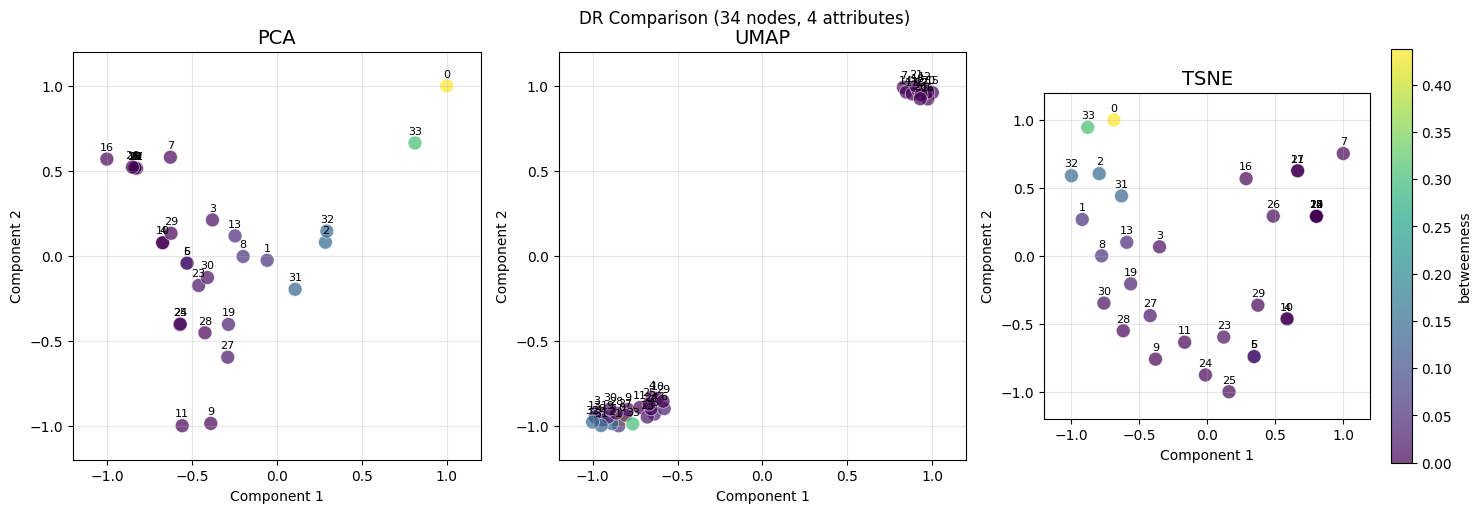

In [11]:
# Compare all DR methods
widget.plot_dr_comparison(color_by='betweenness')

## 9. Create Second Substrate and Compare

In [12]:
# Accept second suggestion if available
if len(widget.suggested_regions) > 1:
    widget.accept_suggestion(1)
    print(f"Now have {len(widget.substrates)} substrates")

Now have 2 substrates


/home/christinoleo/Projects/papers/nodeSubstrates/implementation/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


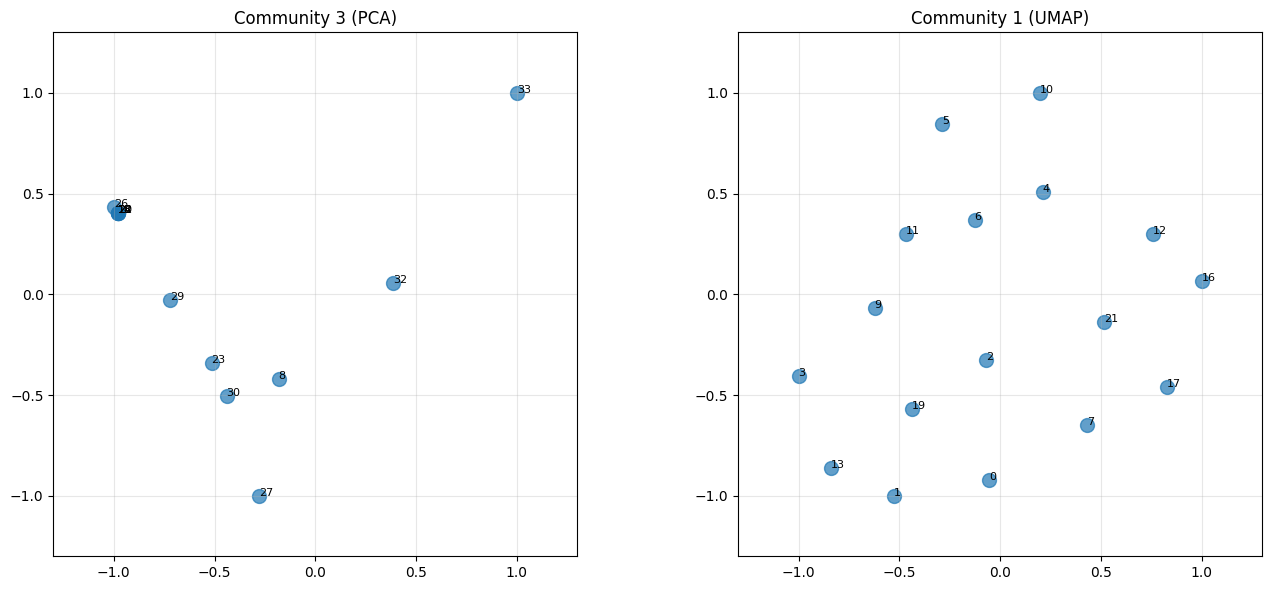

In [13]:
# Plot both substrates side by side
import matplotlib.pyplot as plt

if len(widget.substrate_views) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for i, (ax, substrate) in enumerate(zip(axes, widget.substrate_views)):
        # Get projections
        projections = {p['id']: (p['x'], p['y']) for p in substrate.projections}
        xs = [projections[nid][0] for nid in substrate.node_ids]
        ys = [projections[nid][1] for nid in substrate.node_ids]
        
        ax.scatter(xs, ys, s=100, alpha=0.7)
        for nid in substrate.node_ids:
            ax.annotate(nid, projections[nid], fontsize=8)
        ax.set_title(f"{substrate.label} ({substrate.dr_method.upper()})")
        ax.set_xlim(-1.3, 1.3)
        ax.set_ylim(-1.3, 1.3)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Summary

**Substrate methods:**
- `widget.substrate(0).plot()` - Matplotlib static plot
- `widget.substrate(0).show()` - Interactive mini-widget

**Widget methods:**
- `widget.plot_dr('umap')` - Plot all nodes with DR
- `widget.plot_dr_comparison()` - Compare PCA/UMAP/t-SNE

**Standalone functions:**
- `plot_dr_comparison(G)` - Compare DR without widget
- `inspect_attributes(G)` - Show available attributes